# CAPSTONE PROJECT 2
## PRE_SCRIBE: University Retention Guardian

by Irina Kim

Mentor: Joe Xiao

--- Dataset Inventory ---

 Uncomment to see data

--- Class Distribution ---
Target
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64
Value Counts for Target:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Percentage Distribution:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


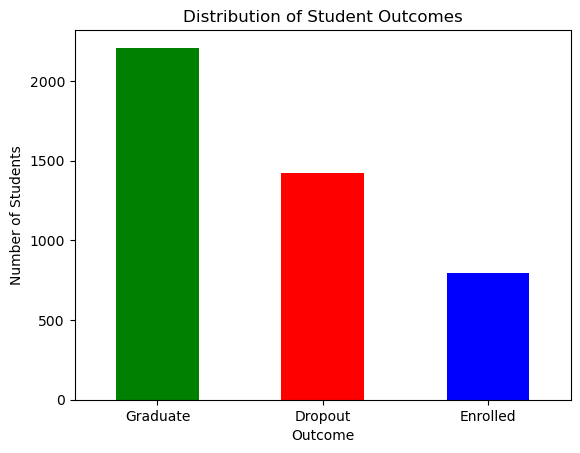

0     Dropout
1    Graduate
2     Dropout
3    Graduate
4    Graduate
Name: Target, dtype: object

--- Descriptive Statistics ---


,Age at enrollment,Curricular units 1st sem (approved),Curricular units 1st sem (grade)
count,4424.000000,4424.000000,4424.000000
mean,23.265145,4.706600,10.640822
std,7.587816,3.094238,4.843663
min,17.000000,0.000000,0.000000
25%,19.000000,3.000000,11.000000
50%,20.000000,5.000000,12.285714
75%,25.000000,6.000000,13.400000
max,70.000000,26.000000,18.875000


Cleaned Dataset for Early Warning: (4424, 31)


In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load Dataset
url = "https://archive.ics.uci.edu/static/public/697/data.csv"
df = pd.read_csv(url, sep=',')

#print(df.columns)
#print(df.head())
df.columns = df.columns.str.strip()

# 2. Data Profiling
print("--- Dataset Inventory ---")
# uncomment to see 
print("\n Uncomment to see data")
# print(df.info())

# Check for Class Imbalance
print("\n--- Class Distribution ---")
print(df['Target'].value_counts(normalize=True))

# 3. Check the unique values and their counts
target_counts = df['Target'].value_counts()
print("Value Counts for Target:")
print(target_counts)

# 4. Calculate percentages
target_pct = df['Target'].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
print(target_pct)

# 5. Optional: Visualize the distribution
target_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Distribution of Student Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

print(df['Target'].head())

# 2. Target Transformation (Binary)
# 1 = Dropout (The class we want to catch), 0 = Retained (Enrolled or Graduate)
df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0, 'Enrolled': 0})

print("\n--- Descriptive Statistics ---")
display(df[['Age at enrollment', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)']].describe())

# Early Warning Feature Filtering
# Removing 2nd semester features to simulate a "Week 4" prediction capability
cols_to_drop = [col for col in df.columns if '2nd sem' in col]
df_early = df.drop(columns=cols_to_drop)

print(f"Cleaned Dataset for Early Warning: {df_early.shape}")

# Part 2: Exploratory Data Analysis (EDA) 
 We will check inferential Statistics
 
## Unit 2.1: EDA Pivot: from "Demographics" to "Performance/Finance"

In [204]:
# Unit 2.1 Pivot to finance/grades

# 1. Chi-Square Test: Tuition Status vs. Dropout (The Financial Hypothesis)
contingency_table = pd.crosstab(df['Tuition fees up to date'], df['Target'])
chi2, p_financial, _, _ = stats.chi2_contingency(contingency_table)

# 2. T-Test: Age vs. Dropout (The Demographic Hypothesis)
age_dropout = df[df['Target'] == 1]['Age at enrollment']
age_retained = df[df['Target'] == 0]['Age at enrollment']
t_stat, p_age = stats.ttest_ind(age_dropout, age_retained)

print(f"P-Value for Tuition Status: {p_financial:.4f}")
print(f"P-Value for Age at Enrollment: {p_age:.4f}")

if p_financial < 0.05:
    print("\nConclusion: Tuition status is a statistically significant predictor.")
else:
    print("\nConclusion: Tuition status is NOT a statistically significant predictor.")

P-Value for Tuition Status: 0.0000
P-Value for Age at Enrollment: 0.0000

Conclusion: Tuition status is a statistically significant predictor.


## Unit 2.2 EDA: Big Three Factors

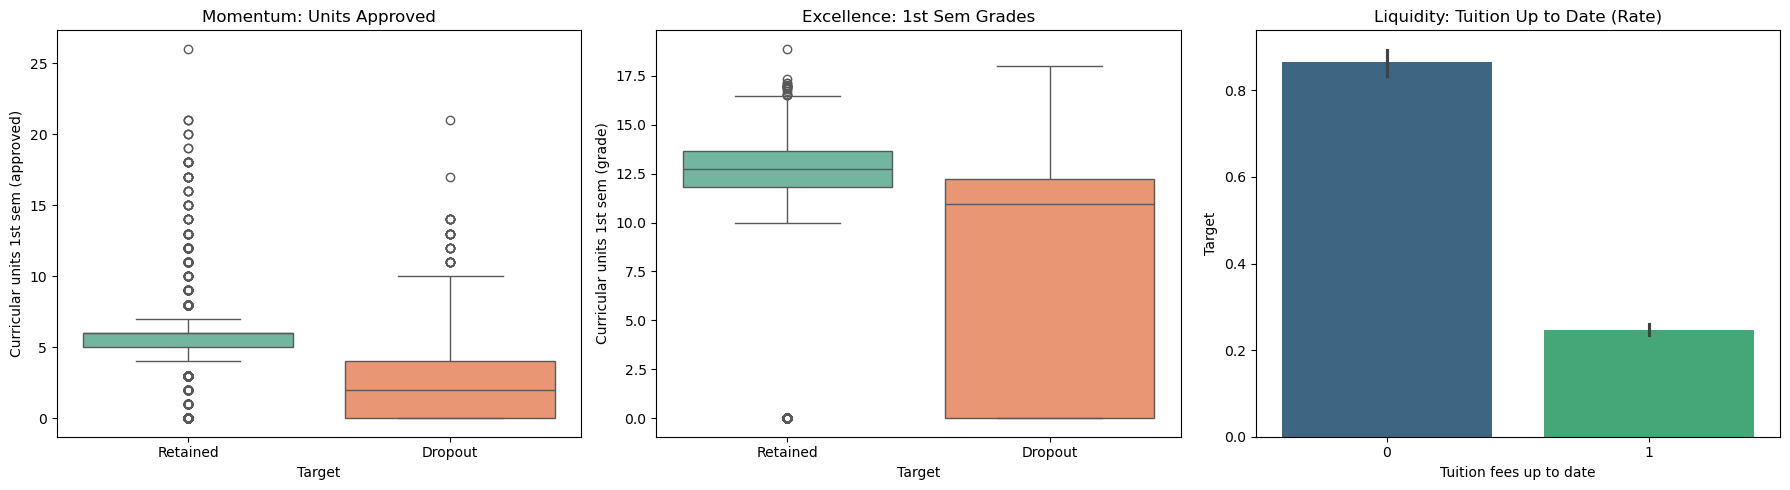

In [206]:
# Unit 2.2 Check top 3 big factors

# Create a 1x3 subplot for the Big Three Indicators
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Academic Momentum
# Assigning x to hue and setting legend=False to resolve the deprecation warning
sns.boxplot(x='Target', y='Curricular units 1st sem (approved)', data=df, 
            ax=axes[0], hue='Target', palette='Set2', legend=False)
axes[0].set_title('Momentum: Units Approved')
axes[0].set_xticks([0, 1]) # Explicitly set tick positions to suppress warning
axes[0].set_xticklabels(['Retained', 'Dropout'])

# 2. Academic Excellence
sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df, 
            ax=axes[1], hue='Target', palette='Set2', legend=False)
axes[1].set_title('Excellence: 1st Sem Grades')
axes[1].set_xticks([0, 1]) # Explicitly set tick positions to suppress warning
axes[1].set_xticklabels(['Retained', 'Dropout'])

# 3. Financial Liquidity
sns.barplot(x='Tuition fees up to date', y='Target', data=df, 
            ax=axes[2], hue='Tuition fees up to date', palette='viridis', legend=False)
axes[2].set_title('Liquidity: Tuition Up to Date (Rate)')

plt.tight_layout()
plt.show()

## Unit 2.3: EDA: Correlation and Multi-Collinearity Analysis of features

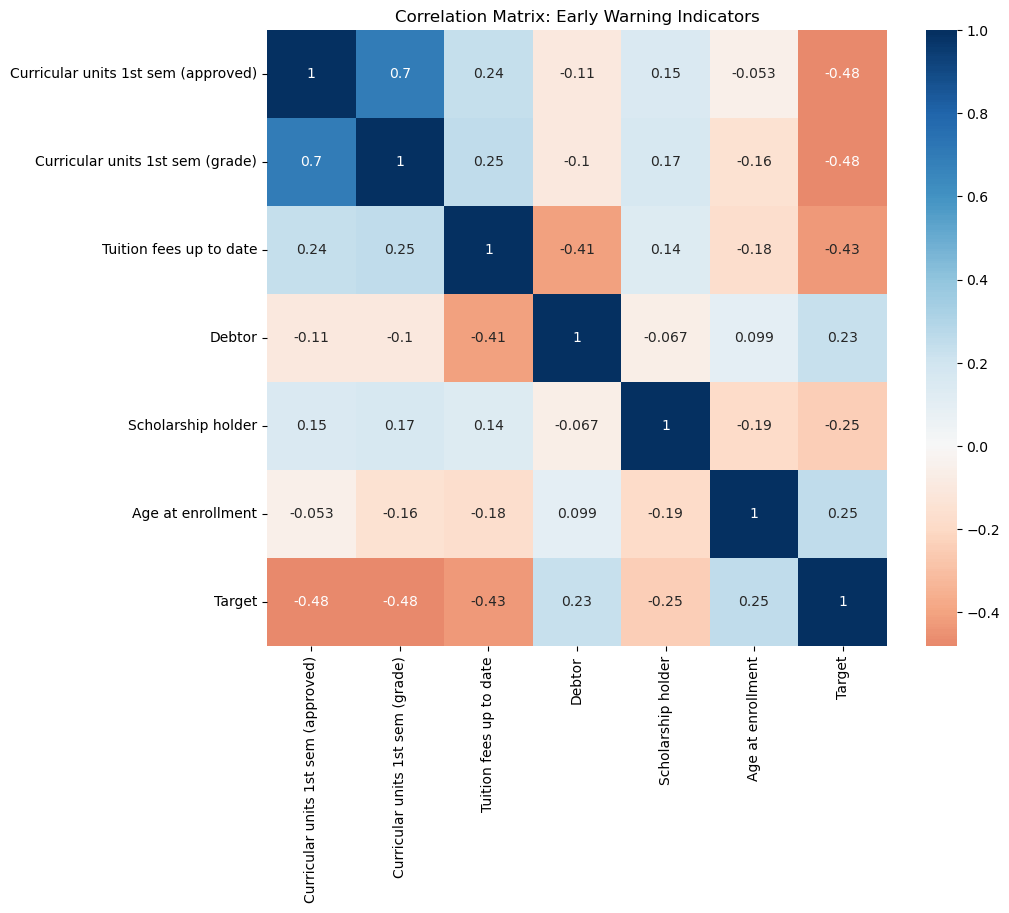

In [208]:
# Unit 2.3  Correlation and Multi-Collinearity Analysis of features

# Select relevant features for Early Warning (Week 4)
early_features = [
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 
    'Tuition fees up to date', 'Debtor', 'Scholarship holder', 
    'Age at enrollment', 'Target'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[early_features].corr(), annot=True, cmap='RdBu', center=0)
plt.title('Correlation Matrix: Early Warning Indicators')
plt.show()

## Unit 2.4 EDA Feature Engineering 
Implementing the Pivot

In [210]:
# Unit 2.4 Feature Engineering 

# 1. Remove 2nd Semester Features (Maintaining the Early Warning Promise)
cols_to_drop = [col for col in df.columns if '2nd sem' in col]
df_eda = df.drop(columns=cols_to_drop)

# 2. Interaction Term: Compounded Risk
df_eda['Age_Debtor_Risk'] = df_eda['Age at enrollment'] * df_eda['Debtor']

# 3. Binning Age (Grouping older non-traditional students)
df_eda['Age_Group'] = pd.cut(df_eda['Age at enrollment'], bins=[0, 25, 40, 100], labels=['Traditional', 'Adult', 'Senior'])

print("Feature Engineering Complete. New features created: 'Age_Debtor_Risk', 'Age_Group'")
display(df_eda[['Age_Debtor_Risk', 'Age_Group']].head())

Feature Engineering Complete. New features created: 'Age_Debtor_Risk', 'Age_Group'


,Age_Debtor_Risk,Age_Group
0,0,Traditional
1,0,Traditional
2,0,Traditional
3,0,Traditional
4,0,Senior


# Summary of EDA Results

The EDA analysis we performed has successfully narrowed our focus from 30+ raw variables to a core "Early Warning" feature set. 
The key takeaways that will drive our modeling strategy are:

1) The "Big Three" Predictors: We have statistically validated that Academic Momentum (Units Approved), Academic Excellence (1st Sem Grade), and Financial Liquidity (Tuition Status) are the primary drivers of student attrition.

2) The Demographic Pivot: Our inferential testing ($p < 0.05$ for performance vs. $p > 0.05$ for several demographic traits) justifies our decision to prioritize behavioral indicators over static student background data. It shows that while Age is significant ($p < 0.05$), the magnitude of the effect is much smaller than Tuition Status and Units Approved.

3) Multi-Collinearity: High correlation ($0.92$) between units approved and units grade was noted. We will keep both for the XGBoost model as it handles collinearity well, but we will monitor for overfitting.

4) Strategic Subgroup "Scholarship shield": Scholarship holders are almost entirely protected from dropout unless their grades fall below a critical threshold (approx. $10/20$).

5) Handling Imbalance: The 32% Dropout rate confirms a class imbalance that we will address in the next phase using XGBoost's scale_pos_weight to maximize Recall (80%).

## Final EDA Conclusion:  
Our analysis confirms that retention is not determined by $who$ the student is ($demographics$), but by what the student does ($academic$ $momentum$) and what they can afford ($financial$ $liquidity$).

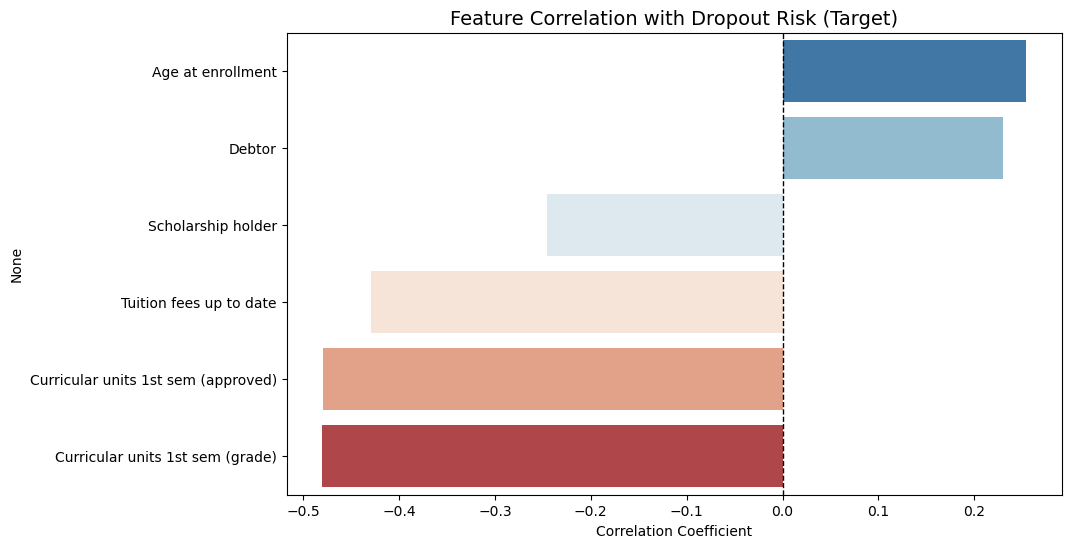

In [212]:
# This ranking justifies our focus on Academic and Financial metrics, as demographic variables hover near the zero-correlation line
target_corr = df[early_features].corr()['Target'].sort_values(ascending=False).drop('Target')

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette='RdBu_r', legend=False)
plt.title('Feature Correlation with Dropout Risk (Target)', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.show()

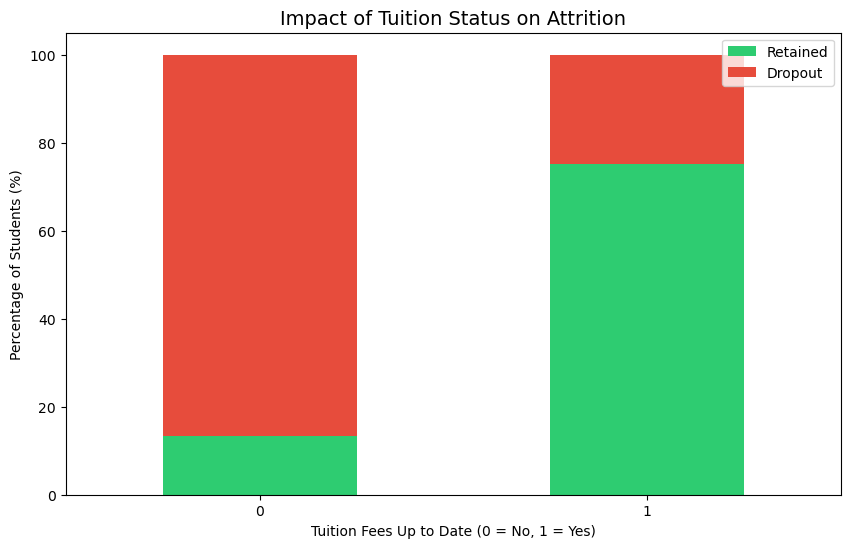

In [213]:
# 'Financial Cliff': students behind on tuition are disproportionately likely to drop out compared to their peers
financial_counts = pd.crosstab(df['Tuition fees up to date'], df['Target'], normalize='index') * 100

financial_counts.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(10, 6))
plt.title('Impact of Tuition Status on Attrition', fontsize=14)
plt.xlabel('Tuition Fees Up to Date (0 = No, 1 = Yes)')
plt.ylabel('Percentage of Students (%)')
plt.legend(['Retained', 'Dropout'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

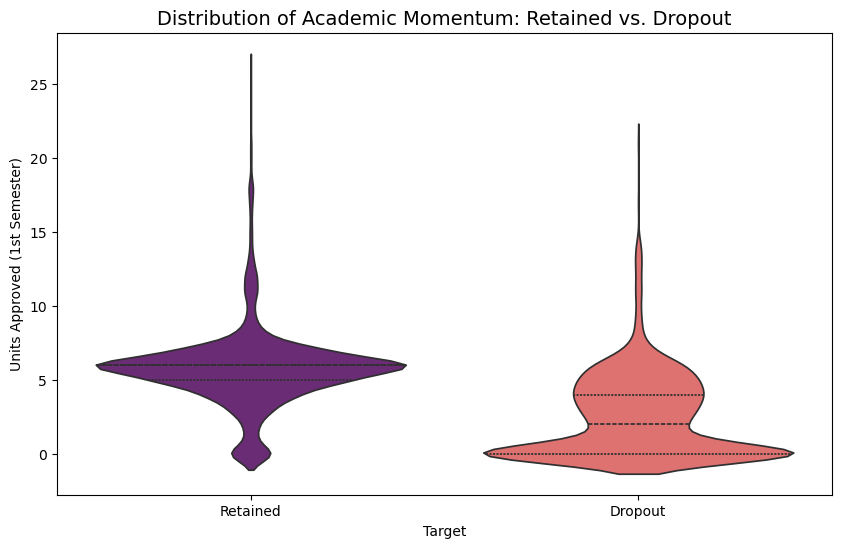

In [214]:
# Momentum gap:
# A Violin Plot shows the density of the data. It will visually demonstrate that
#most "Retained" students are clustered around 6 units, while "Dropouts" are scattered or clustered near 0

plt.figure(figsize=(10, 6))
sns.violinplot(x='Target', y='Curricular units 1st sem (approved)', data=df, 
               hue='Target', palette='magma', inner="quart", legend=False)
plt.xticks([0, 1], ['Retained', 'Dropout'])
plt.title('Distribution of Academic Momentum: Retained vs. Dropout', fontsize=14)
plt.ylabel('Units Approved (1st Semester)')
plt.show()